# PCA+SVC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
DATASET_PATH = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\processed\dataset.npz"
OUTPUT_DIR   = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results"
 
# ── Best Parameters (found during tuning) ─────────────────────────────────────
PCA_COMPONENTS = 300
C = 10
GAMMA = 0.001
RANDOM_SEED = 42

In [3]:
def load_data(path):
    """Load the augmented dataset."""
    print("Loading augmented dataset...")
    data = np.load(path)
 
    X_train = np.concatenate([data['X_train'], data['X_val']])
    y_train = np.concatenate([data['y_train'], data['y_val']])
    X_test  = data['X_test']
    y_test  = data['y_test']
 
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples:     {len(X_test)}")
    print(f"  Features:         {X_train.shape[1]:,}\n")
    
    # Subsample 20% of augmented training data so SVM doesn't freeze
    print("Subsampling 20% of training data...")
    idx     = np.random.choice(len(X_train), size=int(len(X_train) * 0.2), replace=False, )
    X_train = X_train[idx]
    y_train = y_train[idx]
    print(f"  Subsampled training samples: {len(X_train)}\n")

    return X_train, X_test, y_train, y_test

In [4]:
def plot_confusion_matrix(y_true, y_pred, filename):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'PSA {i}' for i in range(1, 11)],
        yticklabels=[f'PSA {i}' for i in range(1, 11)]
    )
    plt.title(f'PCA+SVM (PCA={PCA_COMPONENTS}, C={C}, gamma={GAMMA})\nAugmented Dataset')
    plt.ylabel('True Grade')
    plt.xlabel('Predicted Grade')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"Confusion matrix saved to: {save_path}")

In [5]:
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
 
    # Load data
    X_train, X_test, y_train, y_test = load_data(DATASET_PATH)
 
    # Build and train model
    print(f"{'='*50}")
    print(f"Training PCA+SVM on augmented dataset...")
    print(f"  PCA components: {PCA_COMPONENTS}")
    print(f"  C:              {C}")
    print(f"  gamma:          {GAMMA}")
    print(f"{'='*50}\n")
 
    model = Pipeline([
        ('pca', PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)),
        ('svm', SVC(kernel='rbf', C=C, gamma=GAMMA, random_state=RANDOM_SEED))
    ])
 
    model.fit(X_train, y_train)
    print("Training complete!\n")
 
    # Evaluate
    preds      = model.predict(X_test)
    accuracy   = accuracy_score(y_test, preds)
    within_one = np.mean(np.abs(y_test - preds) <= 1)
 
    print(f"{'='*50}")
    print(f"Results on Test Set")
    print(f"{'='*50}")
    print(f"  Exact accuracy:  {accuracy*100:.1f}%  (baseline was 52.9%)")
    print(f"  Within 1 grade:  {within_one*100:.1f}%  (baseline was 75.0%)")
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, preds,
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
 
    # Save confusion matrix
    plot_confusion_matrix(y_test, preds, "svm_augmented_confusion.png")
 
    # Save results to text file
    results_path = os.path.join(OUTPUT_DIR, 'svm_augmented_results.txt')
    with open(results_path, 'w', encoding='utf-8') as f:
        f.write(f"PCA + SVM Final Results (Augmented Dataset)\n{'='*50}\n\n")
        f.write(f"Parameters:\n")
        f.write(f"  PCA components: {PCA_COMPONENTS}\n")
        f.write(f"  C:              {C}\n")
        f.write(f"  gamma:          {GAMMA}\n\n")
        f.write(f"Results:\n")
        f.write(f"  Exact accuracy:  {accuracy*100:.1f}%\n")
        f.write(f"  Within 1 grade:  {within_one*100:.1f}%\n\n")
        f.write(f"Classification Report:\n")
        f.write(classification_report(
            y_test, preds,
            target_names=[f'PSA {i}' for i in range(1, 11)],
            zero_division=0
        ))
    print(f"\nResults saved to: {results_path}")
    print("\nAll done!")

Loading augmented dataset...
  Training samples: 6487
  Test samples:     1145
  Features:         150,528

Subsampling 20% of training data...
  Subsampled training samples: 1297

Training PCA+SVM on augmented dataset...
  PCA components: 150
  C:              10
  gamma:          0.001

Training complete!

Results on Test Set
  Exact accuracy:  33.5%  (baseline was 52.9%)
  Within 1 grade:  70.1%  (baseline was 75.0%)

Classification Report:
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       0.00      0.00      0.00         4
       PSA 3       0.50      0.02      0.03        56
       PSA 4       1.00      0.08      0.15        61
       PSA 5       0.51      0.14      0.22       131
       PSA 6       0.38      0.04      0.07        73
       PSA 7       0.37      0.28      0.32       264
       PSA 8       0.29      0.87      0.44       284
       PSA 9       0.63      0.15      0.24       218
      PSA 1

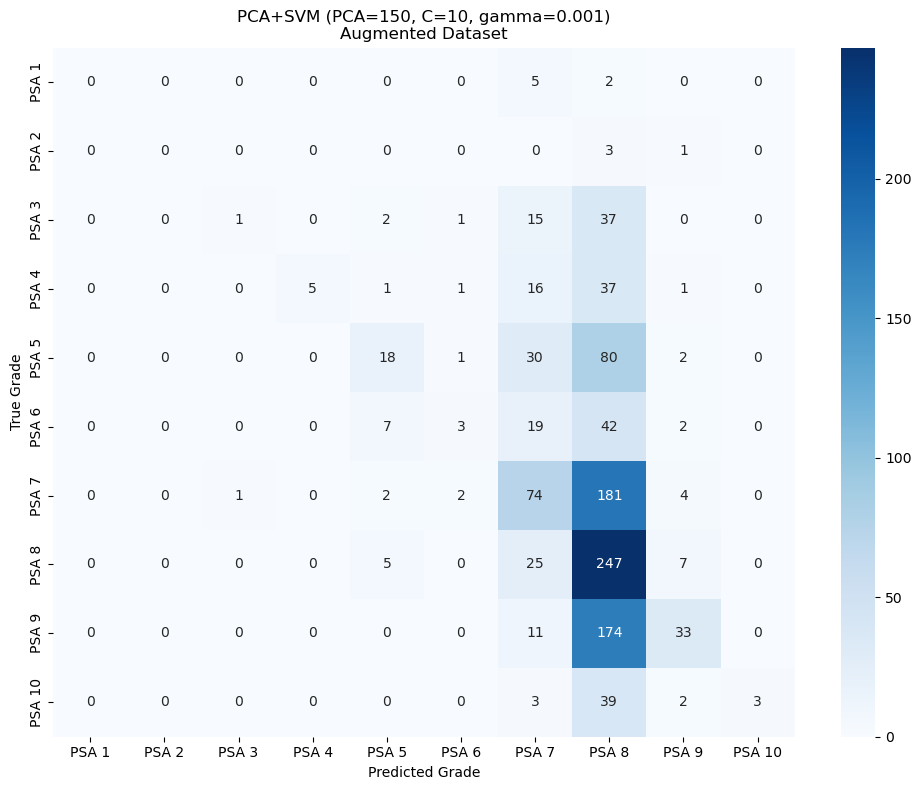

Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_augmented_confusion.png

Results saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\svm_augmented_results.txt

All done!


In [6]:
main()